In [11]:
import pandas as pd
df = pd.read_excel('./data/apt_seoul.xlsx',skiprows=12, thousands=",")

C:\Users\MBC\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [12]:
# 불편한 칼럼이름 변경 - 전용면적(㎡)	,거래금액(만원)
# df.rename() 바뀐 복사본 반환 . 원본이 안바뀜
# 1. df = df.rename(....)
# 2. df.rename(...  ,inplace=True)
df.rename( 
    columns={
        "전용면적(㎡)":"전용면적", 
        "거래금액(만원)":"거래금액"
    }, inplace=True
)
# 시군구를 구,동으로 분리저장
df['구'] = df['시군구'].str.split().str[1]
df['동'] = df['시군구'].str.split().str[2]
# 전용면적 -> 평
df['평'] = df['전용면적'] / 3.3
# 평 -> 평형
def to_ph(x):
    if x < 10: return '10평이하'
    if x < 20: return '10평대'
    if x < 30: return '20평대'
    if x < 40: return '30평대'
    return '40평이상'
df['평형'] = df['평'].apply(to_ph)
# 거래취소된 행 삭제(정상거래된 행)
df = df.query(' 해제사유발생일 == "-" ')
# 가격에 영향없는 칼럼 삭제
df.drop(columns=['NO', '번지', '본번', '부번','매수자', '매도자', '도로명', '해제사유발생일', '거래유형', '중개사소재지',
       '등기일자', '주택유형',], inplace=True)
# 거래금액을 억단위로 변환
df['거래금액'] = df['거래금액'] / 10000
# 계약년월+계약일 -> 요일
df['계약일자'] = pd.to_datetime(
    df['계약년월'].astype(str) + df['계약일'].astype(str).str.zfill(2),
    format='%Y%m%d'
)

df['계약요일'] = df['계약일자'].dt.day_name().map({
    'Monday': '월', 'Tuesday': '화', 'Wednesday': '수',
    'Thursday': '목', 'Friday': '금', 'Saturday': '토', 'Sunday': '일'
})

### 위 아파트 데이터 로딩후 전처리한 결과를 바탕으로 아래 문제를 풀어보세요
### 위 코드를 먼저 실행하세요

## 🟢 기본 탐색

1. 데이터의 행과 열의 개수를 구하시오.

In [13]:
df.shape

(71669, 14)

2. 각 컬럼의 데이터 타입을 확인하시오.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71669 entries, 0 to 76665
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   시군구     71669 non-null  object        
 1   단지명     71669 non-null  object        
 2   전용면적    71669 non-null  float64       
 3   계약년월    71669 non-null  int64         
 4   계약일     71669 non-null  int64         
 5   거래금액    71669 non-null  float64       
 6   동       71669 non-null  object        
 7   층       71669 non-null  int64         
 8   건축년도    71669 non-null  int64         
 9   구       71669 non-null  object        
 10  평       71669 non-null  float64       
 11  평형      71669 non-null  object        
 12  계약일자    71669 non-null  datetime64[ns]
 13  계약요일    71669 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(4), object(6)
memory usage: 8.2+ MB


3. 수치형 데이터의 기초 통계량과 문자형 데이터의 기초 통계량을 구하시오.

In [15]:
display(df.describe()) #수치형 데이터의 기초 통계량
display(df.describe(include="object")) #문자형 데이터의 기초 통계량

,전용면적,계약년월,계약일,거래금액,층,건축년도,평,계약일자
count,71669.00000,71669.000000,71669.000000,71669.000000,71669.000000,71669.000000,71669.000000,71669
mean,75.21771,202527.183343,16.408029,11.944678,9.562977,2003.209923,22.793246,2025-09-17 12:28:11.978400768
min,12.01000,202504.000000,1.000000,0.650000,-2.000000,1961.000000,3.639394,2025-04-07 00:00:00
25%,59.74790,202506.000000,10.000000,6.780000,5.000000,1996.000000,18.105424,2025-06-18 00:00:00
50%,79.94500,202509.000000,17.000000,9.800000,9.000000,2003.000000,24.225758,2025-09-19 00:00:00
75%,84.96000,202512.000000,24.000000,14.550000,13.000000,2012.000000,25.745455,2025-12-11 00:00:00
max,317.36000,202604.000000,31.000000,290.000000,66.000000,2025.000000,96.169697,2026-04-04 00:00:00
std,27.33249,38.121455,8.505771,8.788101,6.358990,11.287104,8.282573,NaN


,시군구,단지명,동,구,평형,계약요일
count,71669,71669,71669,71669,71669,71669
unique,320,4894,318,25,5,7
top,서울특별시 노원구 상계동,현대,상계동,노원구,20평대,토
freq,2411,713,2411,6153,30229,16718


4. 각 칼럼별 결측치갯수를 출력하시오.

In [16]:
df.isnull().sum()

시군구     0
단지명     0
전용면적    0
계약년월    0
계약일     0
거래금액    0
동       0
층       0
건축년도    0
구       0
평       0
평형      0
계약일자    0
계약요일    0
dtype: int64

## 🟡 단일 변수 분석

5. 전체 거래금액의 평균, 최대값, 최소값을 구하시오. 

In [17]:
df['거래금액'].agg(["mean",'max','min'])

mean     11.944678
max     290.000000
min       0.650000
Name: 거래금액, dtype: float64

6. 각 구별 거래 건수를 구하시오.

<Axes: xlabel='구'>

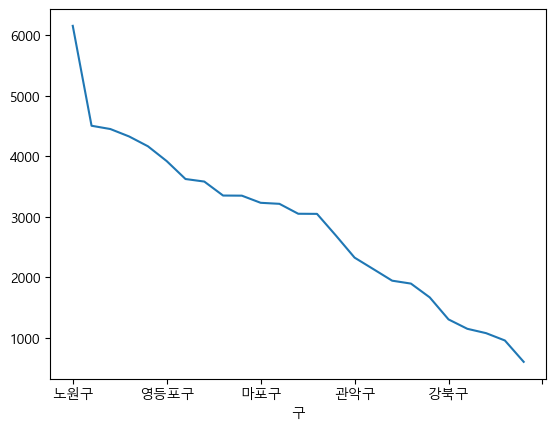

In [26]:
# df['구'].value_counts()
# df.groupby('구')['층'].count().sort_values()
df.groupby('구')['층'].count().sort_values(ascending=False)
# 바그래프로
import matplotlib.pyplot as plt
plt.rc('font',family='Malgun Gothic')
# df['구'].value_counts().plot.bar() #막대그래프
# df['구'].value_counts().plot.barh() #수평막대그래프
df['구'].value_counts().plot.line() #선그래프

7. 평형별 거래 건수를 구하시오.

In [9]:
df['평형'].value_counts()

평형
20평대     30229
10평대     28556
30평대      7219
10평이하     3171
40평이상     2494
Name: count, dtype: int64

8. 층의 분포를 박스플롯과 히스트그램으로 시각화하시오.

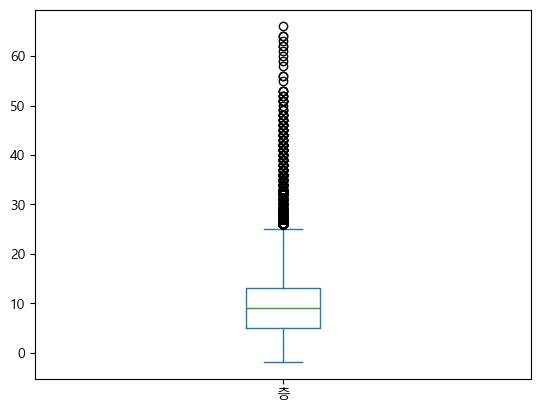

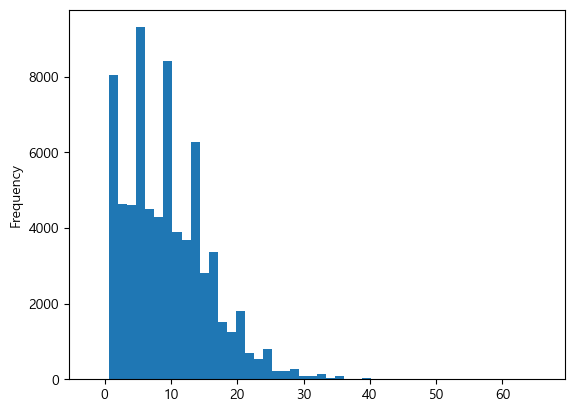

In [28]:
import matplotlib.pyplot as plt
plt.rc('font',family='Malgun Gothic')

df['층'].plot.box()
plt.show()

df['층'].plot.hist(bins=50) #bins 구간개수
plt.show()


## 🟠 그룹 분석

9. 구별 거래금액의 평균, 최대값, 최소값을 구하시오.  


In [29]:
df.groupby('구')['거래금액'].agg(['mean','max','min'])
df.groupby('구')['거래금액'].agg(['mean','max','min']).sort_values('mean',ascending=False)

,mean,max,min
구,,,
강남구,28.351920,190.00,1.3500
서초구,25.226896,96.00,1.9800
용산구,20.111613,167.00,1.5000
송파구,18.683833,67.00,1.5000
성동구,16.326495,290.00,1.3000
마포구,14.777156,40.00,1.0000
광진구,14.191279,39.00,1.1500
양천구,13.296219,43.50,1.2000
동작구,13.177472,35.00,1.1000


In [31]:
df.query('거래금액 == 290')

,시군구,단지명,전용면적,계약년월,계약일,거래금액,동,층,건축년도,구,평,평형,계약일자,계약요일
60199,서울특별시 성동구 성수동1가,아크로서울포레스트,273.928,202506,11,290.0,성수동1가,47,2020,성동구,83.008485,40평이상,2025-06-11,수


10.    계절별 거래금액의 평균, 최대값, 최소값을 구하시오.  

In [34]:
display(df.head(1))
def to_season(x):
    x = x%100
    if x in[12,1,2]: return '겨울'
    if x in[3,4,5]: return '봄'
    if x in[6,7,8]: return '여름'
    return '가을'
df['계절'] = df['계약년월'].apply(to_season)
df.groupby('계절')['거래금액'].agg(['mean','max','min'])

,시군구,단지명,전용면적,계약년월,계약일,거래금액,동,층,건축년도,구,평,평형,계약일자,계약요일
0,서울특별시 은평구 수색동,DMC 진흥,78.2853,202604,4,7.75,수색동,15,2003,은평구,23.722818,20평대,2026-04-04,토


,mean,max,min
계절,,,
가을,12.494941,127.7,0.650
겨울,11.244194,155.0,0.700
봄,11.116617,187.0,0.695
여름,12.586548,290.0,0.700


<Axes: ylabel='계절'>

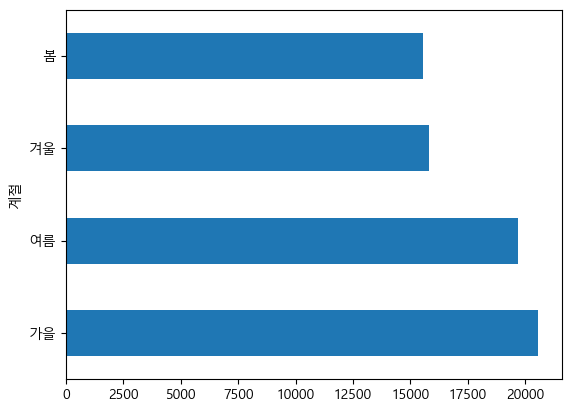

In [39]:
#계절별 거래건수
df['계절'].value_counts()
df['계절'].value_counts().plot.barh()

11. 구별 평형별 평균 거래금액을 구하시오.

<Axes: ylabel='구,평형'>

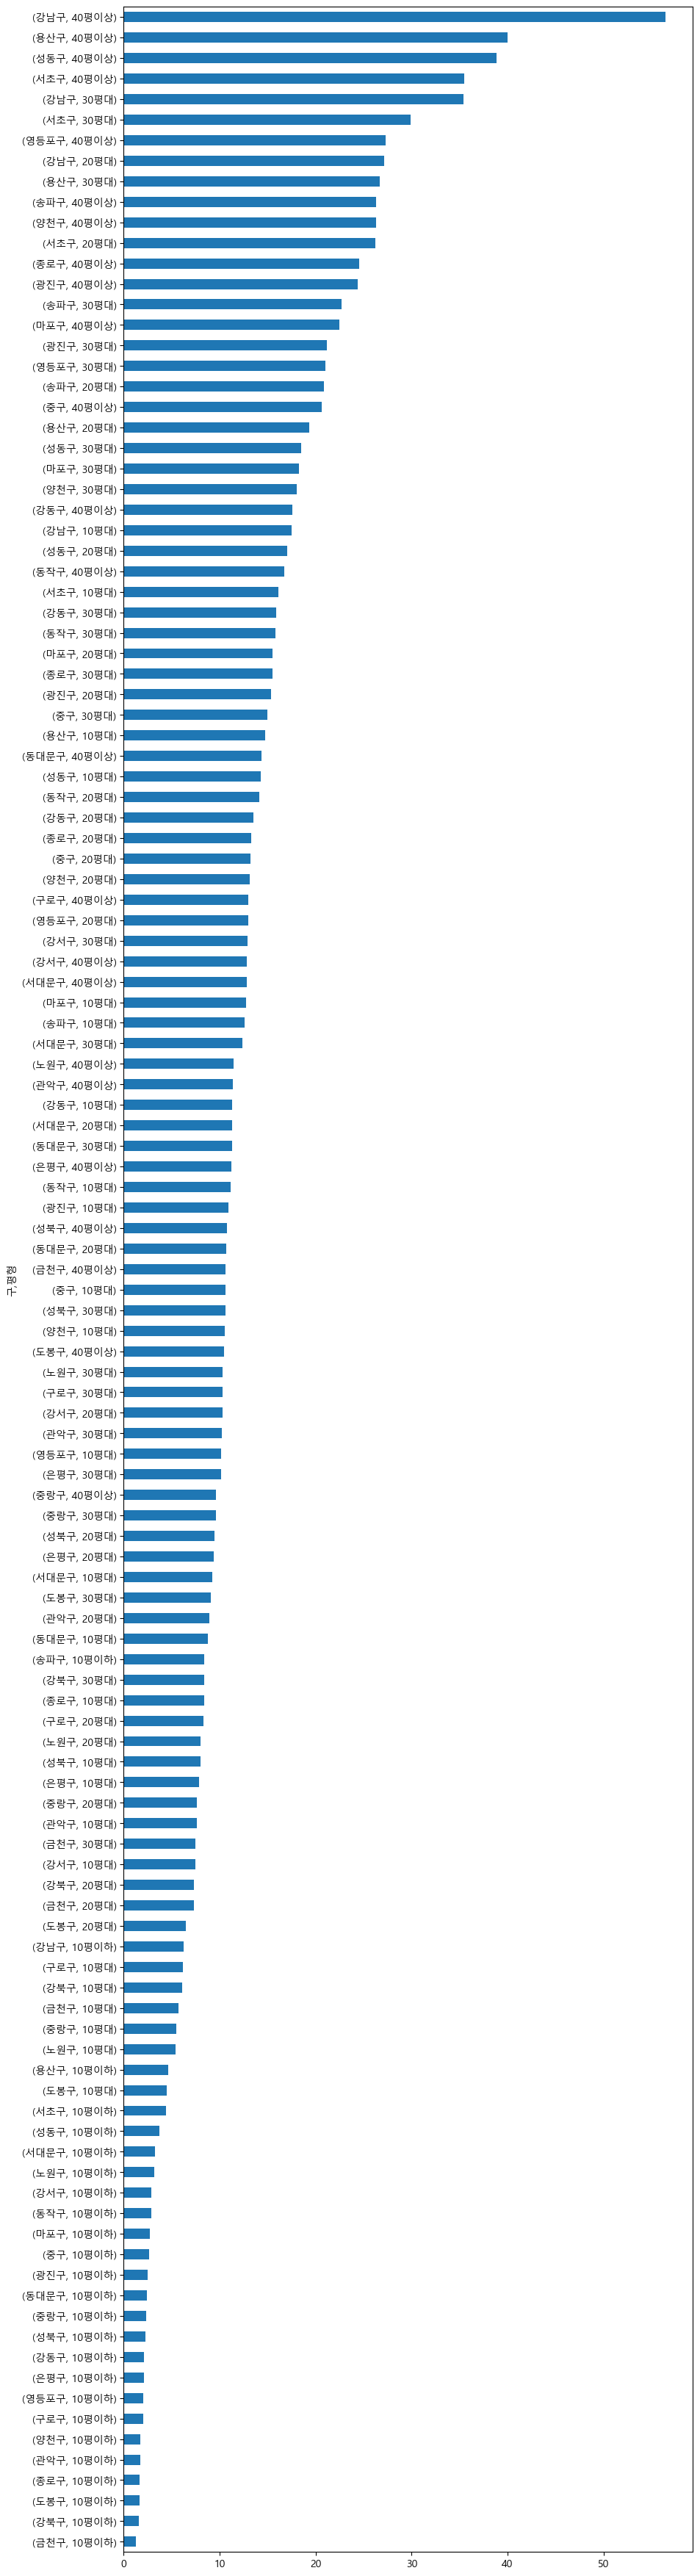

In [47]:
import pandas as pd
pd.set_option('display.max_rows', None) #행개수 제한 해제
pd.set_option('display.max_columns', None) #열 갯수제한 해제
# 제한을 원래값으로 되돌리기
# pd.reset_option('display.max_rows')
# pd.reset_option('display.max_cols')

# df.groupby(['구','평형'])['거래금액'].mean()
# df.groupby(['구','평형'])['거래금액'].mean().plot.barh()
df.groupby(['구','평형'])['거래금액'].mean().sort_values().plot.barh(figsize=(10, 45))

## 🔵 시각화

12. 구별 평균 거래금액을 막대그래프로 표현하시오.

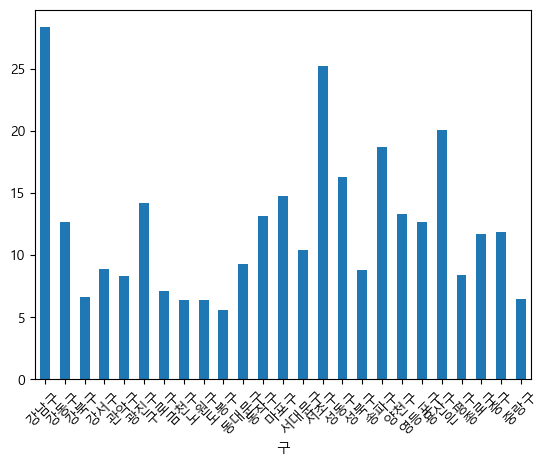

In [53]:
df.groupby('구')['거래금액'].mean().plot.bar(rot=45)
# df.groupby('구')['거래금액'].mean().plot.bar()
plt.show()

13. 전용면적과 거래금액의 관계를 산점도로 표현하시오.

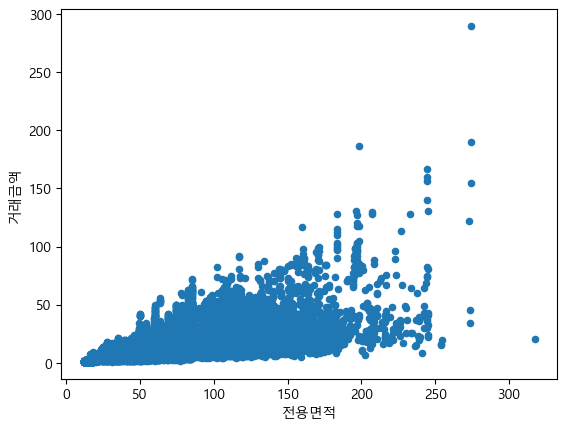

In [49]:
df.plot.scatter(x='전용면적', y='거래금액')
plt.show()

14. 평형별 거래금액 분포를 박스플롯으로 표현하시오.

<Axes: xlabel='평형', ylabel='거래금액'>

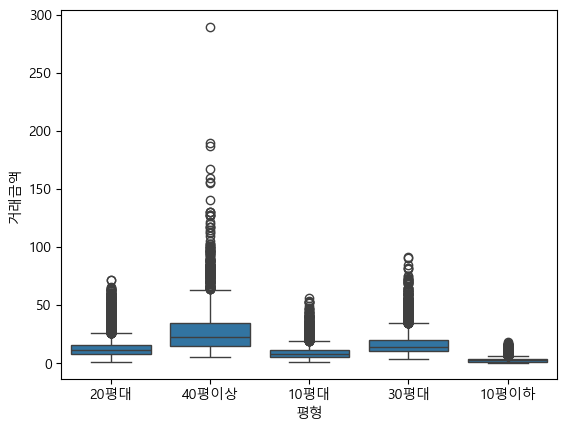

In [50]:
import seaborn as sns
sns.boxplot(data=df, x='평형', y='거래금액')

## 🔴 시간 분석

15. 요일별 거래 건수를 구하시오.

<Axes: xlabel='계약요일'>

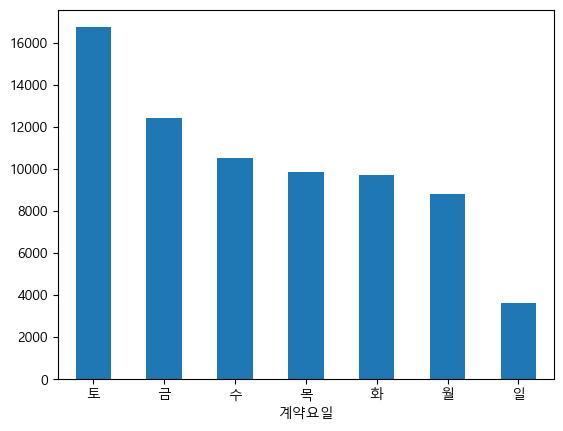

In [55]:
df['계약요일'].value_counts()
df['계약요일'].value_counts().plot.bar(rot=0)

16. 요일별 평균 거래금액을 구하시오.

In [56]:
df.groupby('계약요일')['거래금액'].mean()

계약요일
금    12.394864
목    11.947082
수    11.822990
월    11.808413
일    11.606726
토    11.727544
화    12.120810
Name: 거래금액, dtype: float64

17. 날짜별 거래 건수 추이를 확인하시오.

계약일자
2025-04-07    147
2025-04-08    162
2025-04-09    131
2025-04-10    157
2025-04-11    189
             ... 
2026-03-31     36
2026-04-01     39
2026-04-02     20
2026-04-03      5
2026-04-04      1
Length: 363, dtype: int64


<Axes: ylabel='계약일자'>

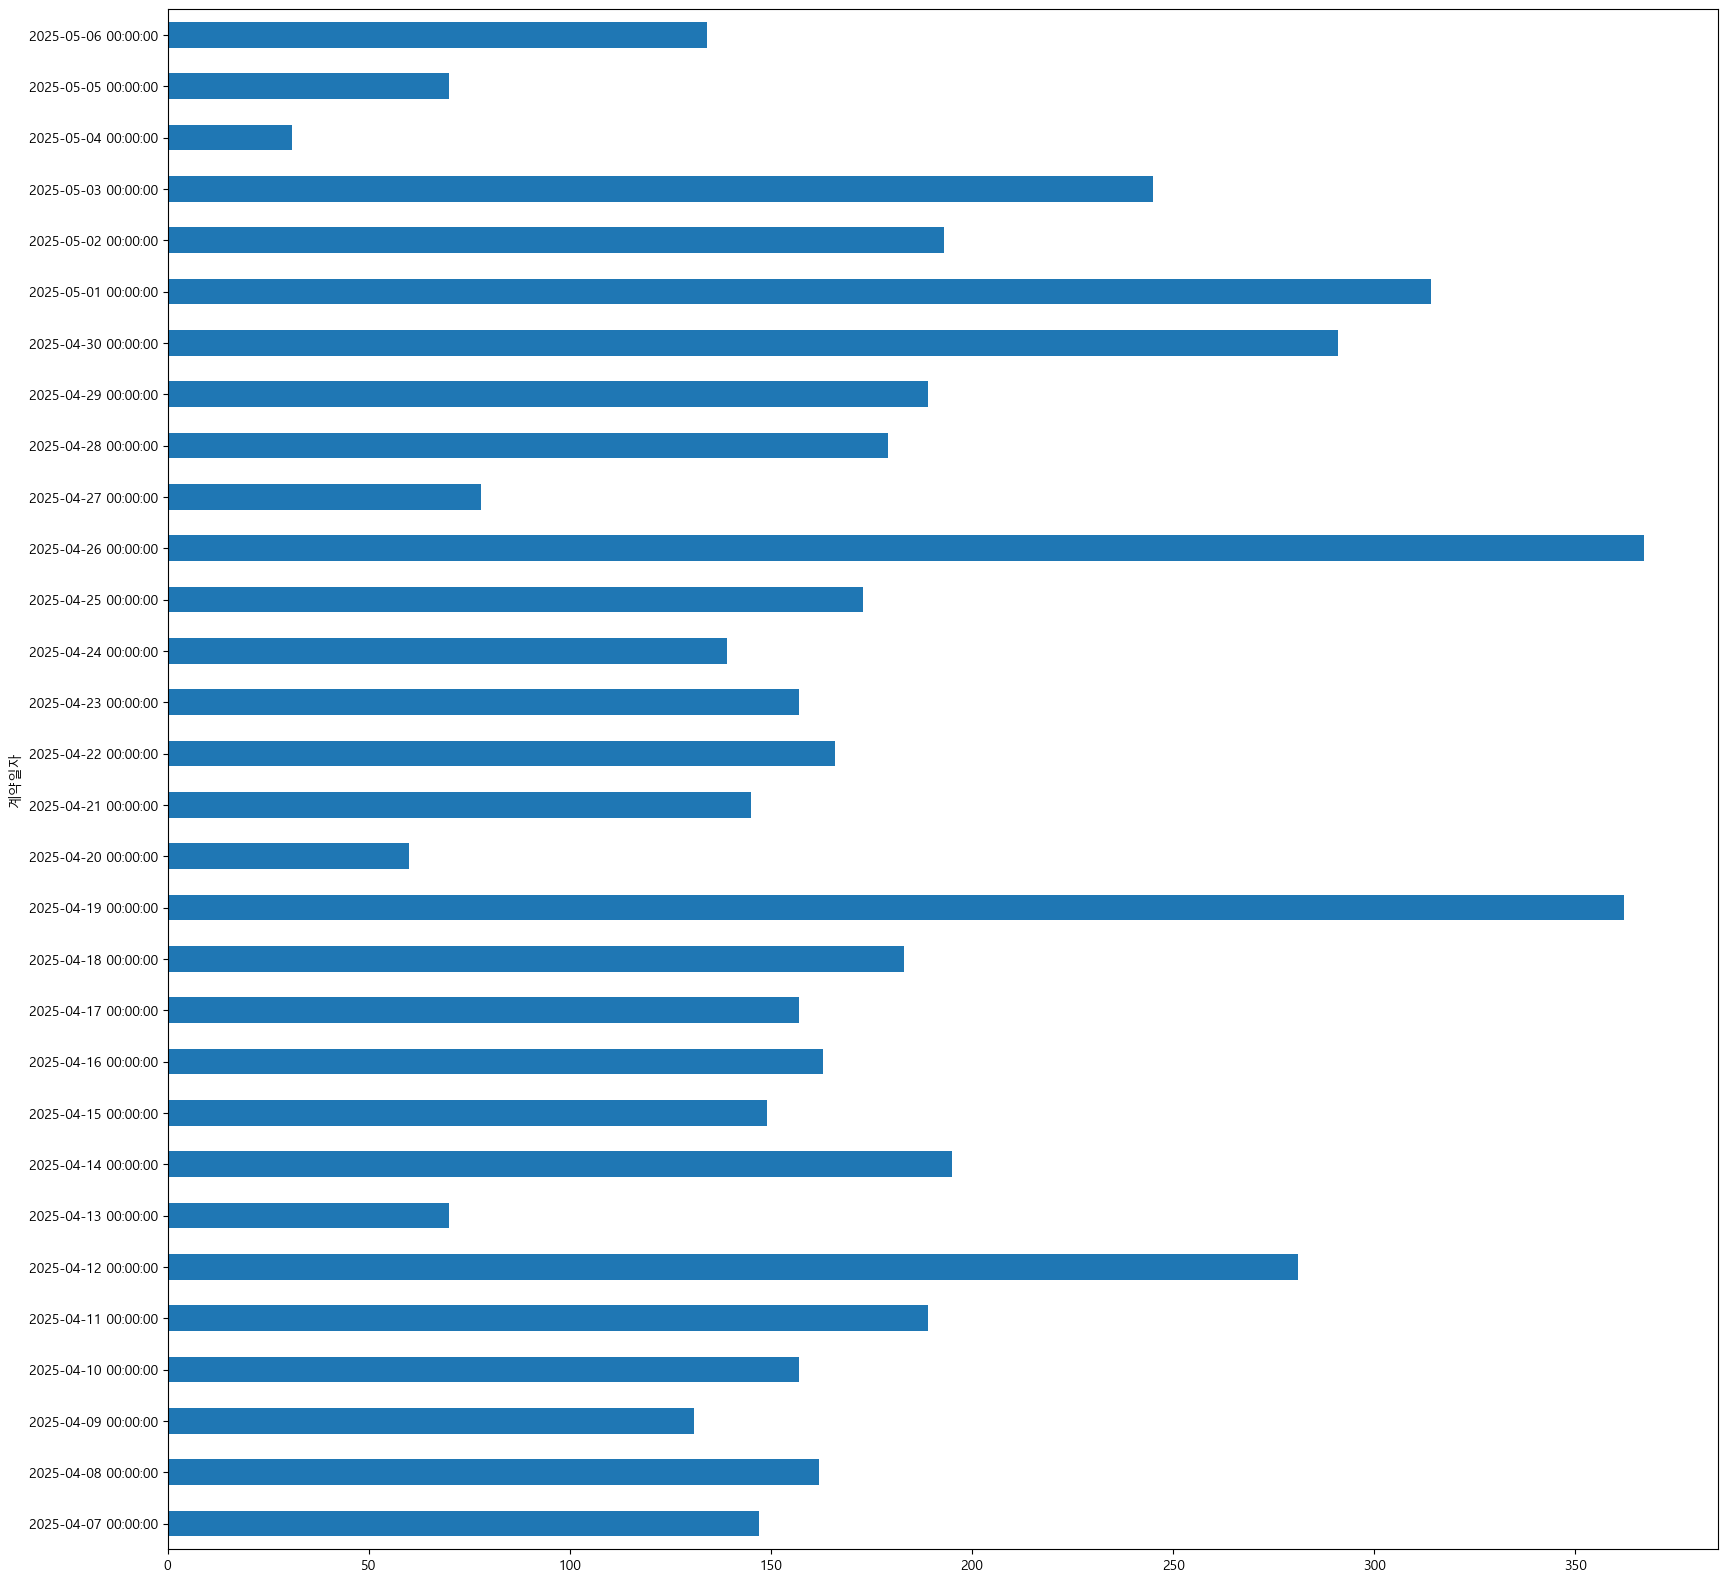

In [65]:
pd.reset_option('display.max_rows')
print(df.groupby('계약일자').size().sort_index()) #sort_index() 값으로 정렬
df.groupby('계약일자').size().sort_index().head(30).plot.barh(figsize=(20,20))

## 🟣 심화 분석

18. 거래 건수가 가장 많은 구 TOP 5를 구하시오.

In [66]:
df['구'].value_counts().head(5)

구
노원구    6153
강동구    4502
강서구    4448
성북구    4325
송파구    4163
Name: count, dtype: int64

19. 거래금액이 가장 높은 상위 10건을 조회하시오.

In [21]:
df.sort_values(by='거래금액', ascending=False).head(10)

,시군구,단지명,전용면적,계약년월,계약일,거래금액,동,층,건축년도,구,평,평형,계약일자,계약요일,계절
60199,서울특별시 성동구 성수동1가,아크로서울포레스트,273.9280,202506,11,290.0,성수동1가,47,2020,성동구,83.008485,40평이상,2025-06-11,수,여름
50587,서울특별시 강남구 청담동,PH129,273.9600,202507,1,190.0,청담동,12,2020,강남구,83.018182,40평이상,2025-07-01,화,여름
64311,서울특별시 성동구 성수동1가,아크로서울포레스트,198.2190,202505,29,187.0,성수동1가,46,2020,성동구,60.066364,40평이상,2025-05-29,목,봄
45639,서울특별시 용산구 한남동,나인원한남,244.3478,202508,5,167.0,한남동,5,2019,용산구,74.044788,40평이상,2025-08-05,화,여름
45341,서울특별시 용산구 한남동,나인원한남,244.3478,202508,8,160.0,한남동,4,2019,용산구,74.044788,40평이상,2025-08-08,금,여름
707,서울특별시 용산구 한남동,나인원한남,244.3478,202603,23,156.5,한남동,4,2019,용산구,74.044788,40평이상,2026-03-23,월,봄
18149,서울특별시 강남구 청담동,PH129,273.9600,202512,12,155.0,청담동,10,2020,강남구,83.018182,40평이상,2025-12-12,금,겨울
13518,서울특별시 용산구 한남동,나인원한남,244.3478,202601,12,140.4,한남동,5,2019,용산구,74.044788,40평이상,2026-01-12,월,겨울
43995,서울특별시 강남구 압구정동,"현대1차(12,13,21,22,31,32,33동)",196.2100,202508,18,130.5,압구정동,6,1976,강남구,59.457576,40평이상,2025-08-18,월,여름
73255,서울특별시 강남구 압구정동,"현대7차(73~77,82,85동)",245.2000,202504,25,130.5,압구정동,8,1979,강남구,74.303030,40평이상,2025-04-25,금,봄


20. 강남3구+용산구와 그외지역의 거래건수,평균거래가격 를 출력하세요.

In [22]:
# 강남3구 + 용산구 리스트
main_area = ['강남구', '서초구', '송파구', '용산구']

# 지역 구분 컬럼 생성
df['지역구분'] = df['구'].apply(lambda x: '핵심지역' if x in main_area else '기타지역')

# 거래건수 + 평균 거래금액
result = df.groupby('지역구분')['거래금액'].agg(['count', 'mean'])

print(result)

      count       mean
지역구분                  
기타지역  61775  10.217206
핵심지역   9894  22.730465


### 3년 전에 비해 가격이 가장 많이 오른 구, 아파트, 평형은?
1. 데이터 수집(국토부 실거래가)
2. 전처리(이전데이터와 동일)
3. 데이터 합치기(옵션)
4. 원하는 값 추출, 결과 생성

In [67]:
#1. 목표 구하기, 2. 데이터 모으기


In [69]:
df.tail()

,시군구,단지명,전용면적,계약년월,계약일,거래금액,동,층,건축년도,구,평,평형,계약일자,계약요일,계절
76661,서울특별시 성북구 하월곡동,월곡두산위브,84.8430,202504,7,8.18,하월곡동,9,2003,성북구,25.710000,20평대,2025-04-07,월,봄
76662,서울특별시 동대문구 장안동,장안위더스빌,84.8500,202504,7,7.78,장안동,16,2011,동대문구,25.712121,20평대,2025-04-07,월,봄
76663,서울특별시 성북구 안암동1가,안암동삼성래미안,59.6983,202504,7,7.60,안암동1가,6,2005,성북구,18.090394,10평대,2025-04-07,월,봄
76664,서울특별시 성북구 정릉동,"산장아파트가동,나동",52.8900,202504,7,3.00,정릉동,1,1977,성북구,16.027273,10평대,2025-04-07,월,봄
76665,서울특별시 중랑구 신내동,신내6대주,39.8400,202504,7,4.05,신내동,12,1996,중랑구,12.072727,10평대,2025-04-07,월,봄
